In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import pyscisci.all as pyscisci
from brokenaxes import brokenaxes
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import LogLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as ticker
from scipy.stats import norm, ks_2samp
import dask.dataframe as dd
from adjustText import adjust_text
from itertools import combinations
from tqdm import tqdm
import pickle
import unicodedata
import html
import regex
import re
from rapidfuzz import process as rf_process
from rapidfuzz import fuzz
import string
import spacy
tqdm.pandas()  # 注册 tqdm 的 DataFrame 扩展

# 定义字体
EF = FontProperties(family = 'DejaVu Sans')
main_path = r'/home/20250114zmz_kd/'
%matplotlib inline

In [2]:
data = r'UseBSForNot/MergeInsthData_1211.csv'
d = pd.read_csv(main_path + data)
del d['Unnamed: 0']
print(d .shape)
d .columns

(3227892, 77)


Index(['work_id', 'fac_pub', 'year', 'paper_type', 'paper_language', 'nwbin',
       'new_word_reuse_times', 'npbin', 'new_phrase_reuse_times', 'novelbin',
       'rao_stirling', 'author_id', 'author_position', 'institution_id',
       'country_code', 'country', 'num_author_log', 'num_inst_log',
       'num_country_log', 'num_reference_log', 'timescited5_log',
       'timescited10_log', 'timescitedall_log', 'ab_length_log',
       'leadership_global_class', 'mean_career_age_log', 'inst_h_index_log',
       'source_id', 'source_h_index_log', 'source_type', 'core_source',
       'Agricultural and Biological Sciences', 'Arts and Humanities',
       'Biochemistry, Genetics and Molecular Biology',
       'Business, Management and Accounting', 'Chemical Engineering',
       'Chemistry', 'Computer Science', 'Decision Sciences', 'Dentistry',
       'Earth and Planetary Sciences', 'Economics, Econometrics and Finance',
       'Energy', 'Engineering', 'Environmental Science', 'Health Professions

In [3]:
d['source_h_index_log'].describe()

count    3.227892e+06
mean     5.309497e+00
std      9.285278e-01
min      0.000000e+00
25%      4.875197e+00
50%      5.429346e+00
75%      5.918894e+00
max      7.474205e+00
Name: source_h_index_log, dtype: float64

In [4]:
d['inst_h_index_log'].describe()

count    3.227886e+06
mean     5.996586e+00
std      6.436586e-01
min      0.000000e+00
25%      5.624018e+00
50%      6.064947e+00
75%      6.434547e+00
max      7.443664e+00
Name: inst_h_index_log, dtype: float64

In [5]:
d['mean_career_age_log'].describe()

count    3.227892e+06
mean     3.108371e+00
std      4.452077e-01
min      6.931472e-01
25%      2.847812e+00
50%      3.130045e+00
75%      3.394508e+00
max      4.836282e+00
Name: mean_career_age_log, dtype: float64

In [6]:
d['fac_pub'].unique()

array(['NonBSF', 'BSF'], dtype=object)

In [7]:
# 使用装置的年发文量
# 装置的BeginYear分布（阶段）
# 年度参与装置研究的作者数量、机构数量、国家数量
# 装置涉及的学科数量
dfac = d[d['fac_pub']=='BSF']
print(dfac .shape)

(285574, 77)


In [8]:
dfac .nunique()

work_id            285574
fac_pub                 1
year                   74
paper_type              1
paper_language          1
                    ...  
timescitedall        1357
source_h_index        478
mean_career_age      9534
ab_length            1464
inst_h_index        17977
Length: 77, dtype: int64

In [9]:
year_facpub = dfac .groupby('year')['work_id'].nunique().reset_index()
print(year_facpub .shape)
year_facpub = year_facpub .rename(columns = {'work_id':'year_facpub'})
year_facpub .columns

(74, 2)


Index(['year', 'year_facpub'], dtype='object')

In [10]:
dnfac = d[d['fac_pub']=='NonBSF']
print(dnfac .shape)

(2942318, 77)


In [11]:
year_nfacpub = dnfac .groupby('year')['work_id'].nunique().reset_index()
print(year_nfacpub .shape)
year_nfacpub = year_nfacpub .rename(columns = {'work_id':'year_nfacpub'})
year_nfacpub .columns

(76, 2)


Index(['year', 'year_nfacpub'], dtype='object')

In [12]:
merge1 = year_nfacpub .merge(year_facpub[['year','year_facpub']],
                             how = 'left', left_on = 'year', right_on = 'year')
merge1['ratio'] = merge1['year_facpub']/(merge1['year_nfacpub']+merge1['year_facpub'])
merge1 = merge1.fillna(0)
print(merge1 .shape)

(76, 4)


In [13]:
facpub = r'ScientificTravelers/0_DataPrepare/0000-BigScienceFacilityDataset.csv'
fp = pd.read_csv(main_path + facpub)
del fp['Unnamed: 0']
print(fp .shape)
fp .columns

(359301, 9)


Index(['MyID', 'work_id', 'couse', 'num_fac', 'facility', 'pub_year',
       'paper_type', 'paper_language', 'is_oa'],
      dtype='object')

In [14]:
fp = fp[fp['pub_year']>=1950]
print(fp .shape)
min_year = fp .groupby('facility')['pub_year'].min().reset_index()
min_year = min_year .rename(columns = {'pub_year':'fac_begin_year'})
print(min_year.shape)
annual_fac = fp .groupby('pub_year')['facility'].nunique().reset_index()
annual_fac = annual_fac .rename(columns = {'facility':'num_fac_annual'})
print(annual_fac .shape)

(359294, 9)
(88, 2)
(76, 2)


In [15]:
fac_pub_authorship = r'ScientificTravelers/0_DataPrepare/0010-FacPubAuthorships.csv'
fpa = pd.read_csv(main_path + fac_pub_authorship)
del fpa['Unnamed: 0']
print(fpa .shape)
fpa .columns

/tmp/ipykernel_1755786/1068019238.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  fpa = pd.read_csv(main_path + fac_pub_authorship)


(7200106, 8)


Index(['work_id', 'author_position', 'author_id', 'institution_id',
       'raw_affiliation_string', 'is_corresponding', 'country_code',
       'country'],
      dtype='object')

In [16]:
fpa = fpa[fpa['work_id'].isin(fp['work_id'].drop_duplicates())]
print(fpa .shape)

(7200102, 8)


In [17]:
fpa = fpa .merge(fp[['work_id','pub_year']], how = 'left', left_on = 'work_id', right_on = 'work_id')
print(fpa .shape)

(7893202, 9)


In [18]:
author = fpa[['work_id','author_id','pub_year']].drop_duplicates()
inst = fpa[['work_id','institution_id','pub_year']].drop_duplicates()
country = fpa[['work_id','country_code','pub_year']].drop_duplicates()
author = author .groupby('pub_year')['author_id'].nunique().reset_index()
inst = inst .groupby('pub_year')['institution_id'].nunique().reset_index()
country = country .groupby('pub_year')['country_code'].nunique().reset_index()

In [19]:
merge2 = author .merge(inst[['pub_year','institution_id']], how = 'left', left_on = 'pub_year', right_on = 'pub_year')
merge2 = merge2 .merge(country[['pub_year','country_code']], how = 'left', left_on = 'pub_year', right_on = 'pub_year')
print(merge2 .shape)
merge2 .columns

(76, 4)


Index(['pub_year', 'author_id', 'institution_id', 'country_code'], dtype='object')

In [20]:
topics = r'UseBSForNot/PubSubfields.csv'
t = pd.read_csv(main_path + topics)
t = t[t['work_id'].isin(fp['work_id'].drop_duplicates())]
print(t .shape)

(852286, 6)


In [21]:
del t['Unnamed: 0']
t .columns

Index(['work_id', 'subfield_id', 'field_id', 'domain_id',
       'domain_display_name'],
      dtype='object')

In [22]:
t = t .merge(fp[['work_id','pub_year']], how = 'left', left_on = 'work_id', right_on = 'work_id')
print(t .shape)
t .columns

(983650, 6)


Index(['work_id', 'subfield_id', 'field_id', 'domain_id',
       'domain_display_name', 'pub_year'],
      dtype='object')

In [23]:
num_sub = t .groupby(['pub_year','domain_display_name'])['subfield_id'].nunique().reset_index()
print(num_sub .shape)
num_sub .head(3)

(231, 3)


,pub_year,domain_display_name,subfield_id
0,1950,Physical Sciences,2
1,1951,Physical Sciences,7
2,1952,Physical Sciences,3


In [24]:
num_sub['domain_display_name'].unique()

array(['Physical Sciences', 'Life Sciences', 'Social Sciences',
       'Health Sciences'], dtype=object)

/tmp/ipykernel_1755786/618601977.py:13: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax_a.set_ylim(0, 30000)


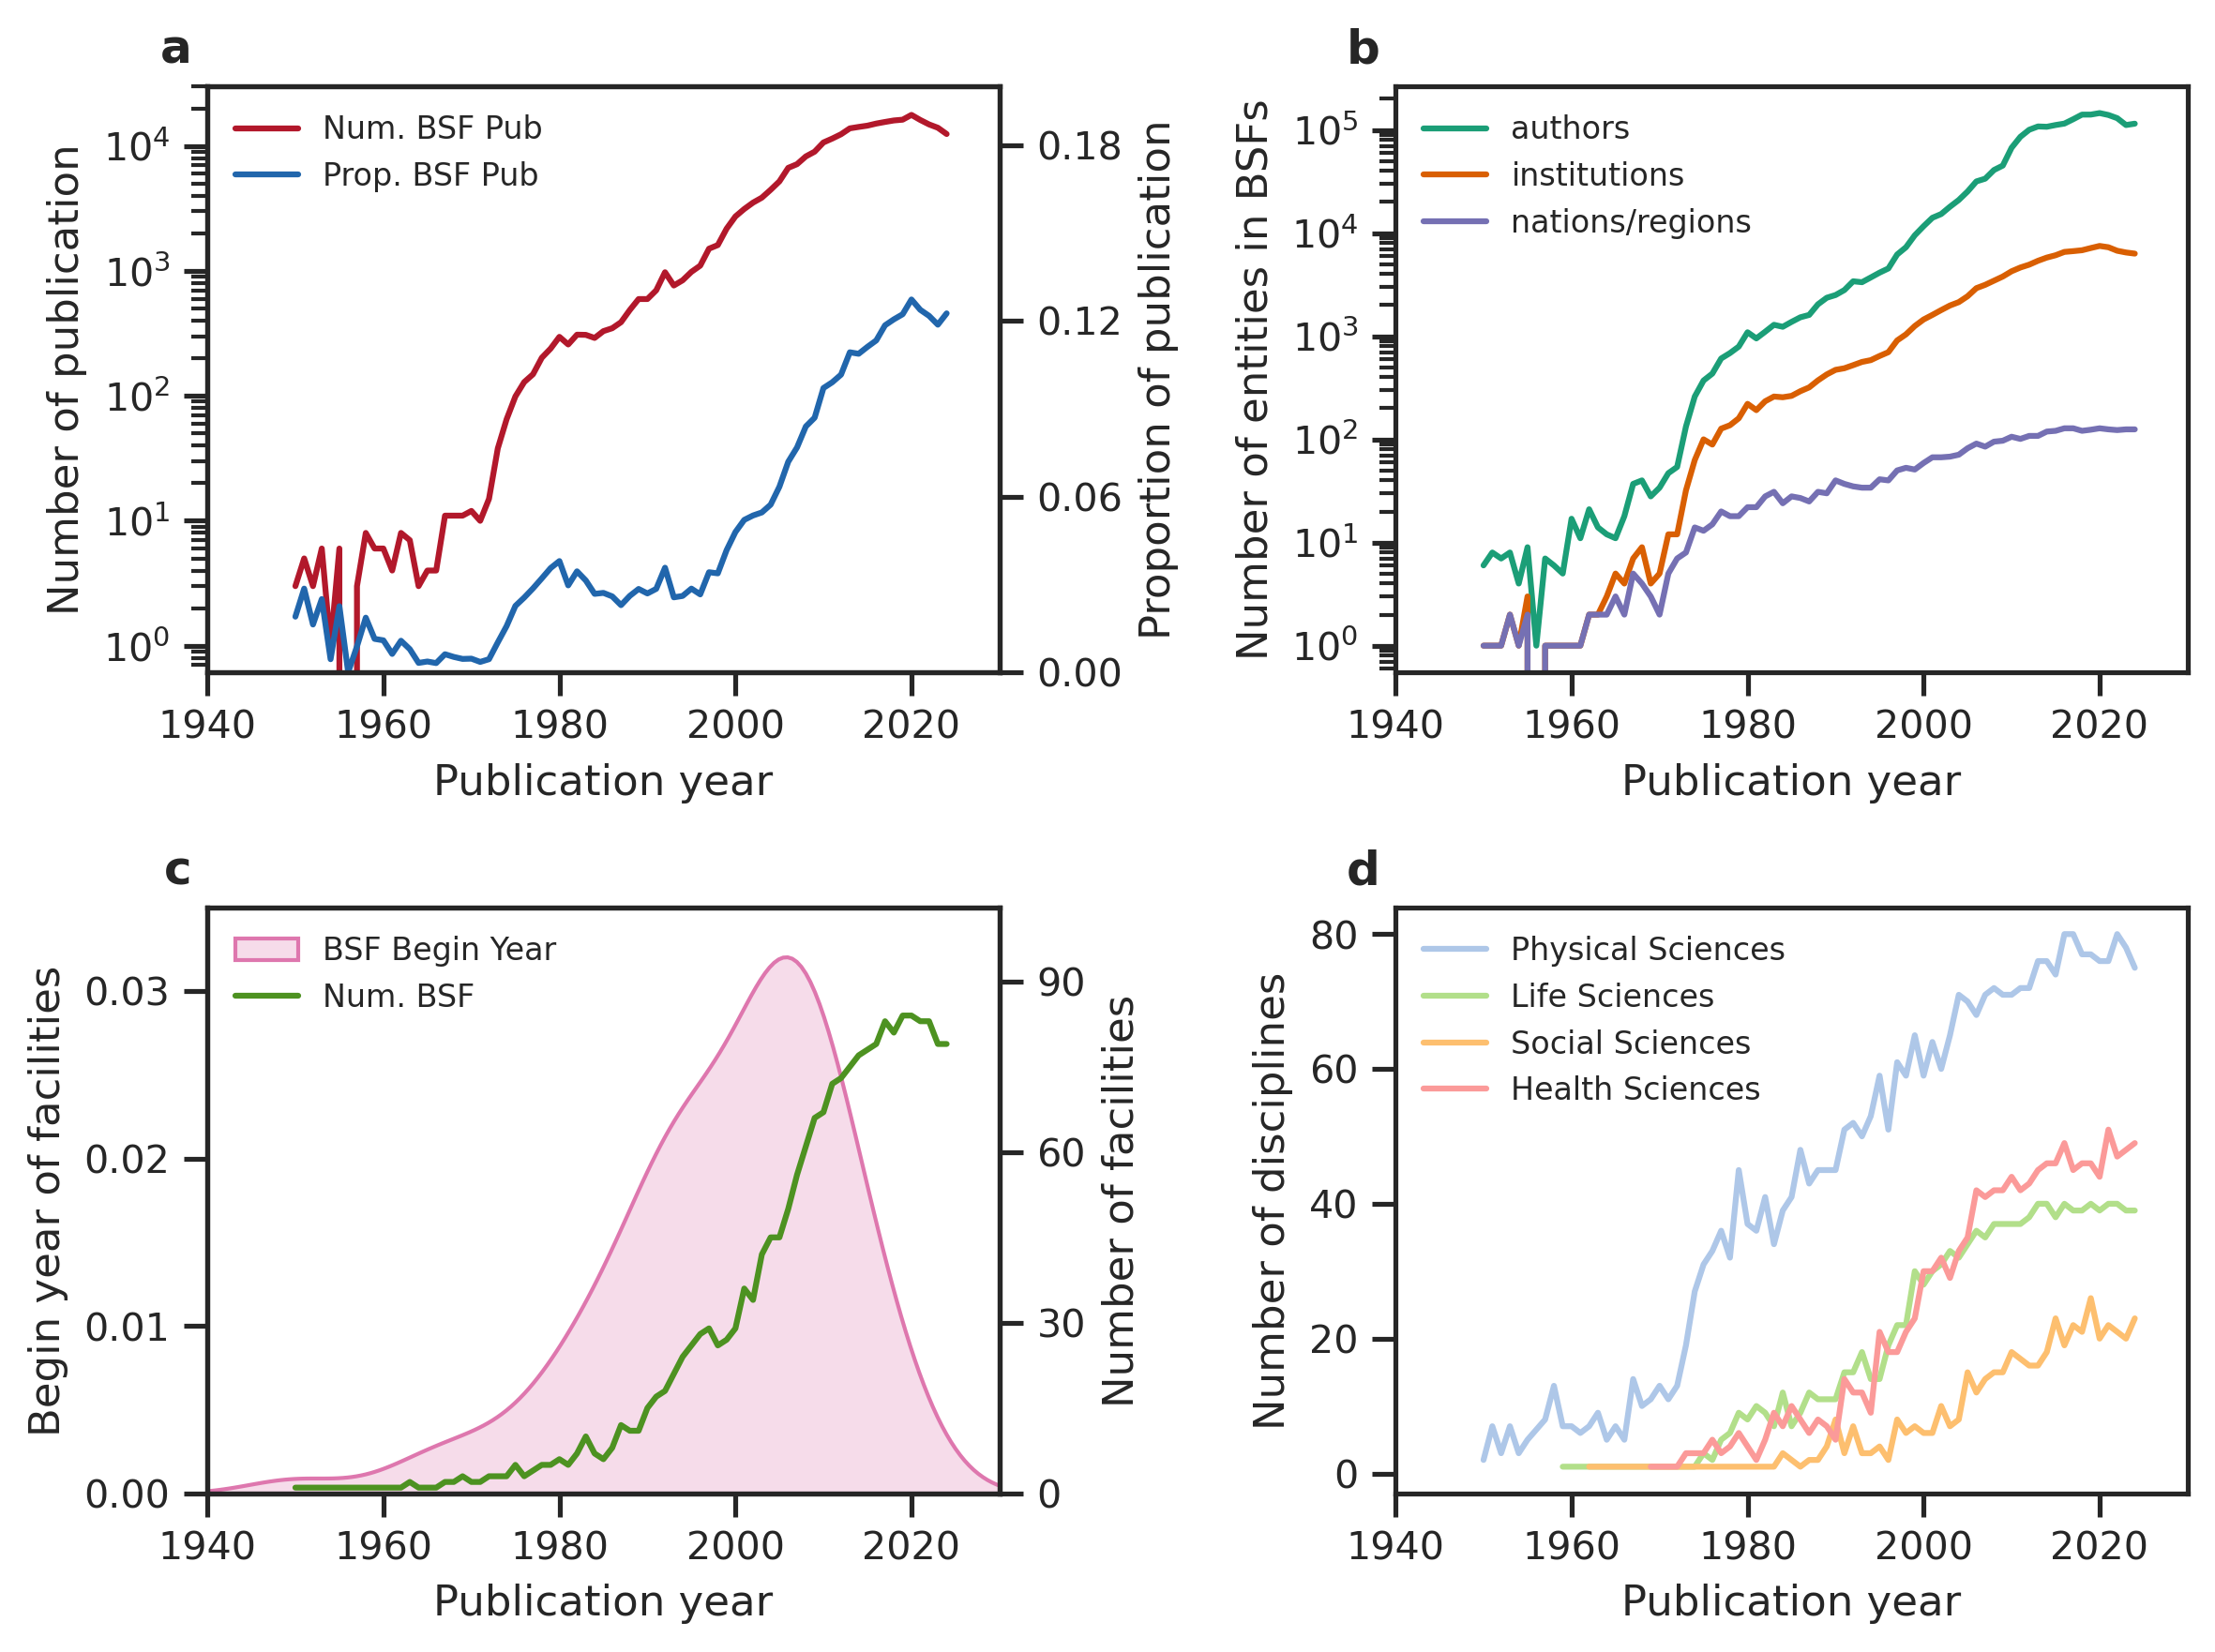

In [25]:
fig = plt.figure(figsize=(8, 6), dpi=300)
sns.set(style='ticks', font_scale=0.9)
outer = gridspec.GridSpec(2, 1, height_ratios=[1, 1])

gs1 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0], width_ratios=[1,1], wspace=0.5)
ax_a = fig.add_subplot(gs1[0])
df = merge1
df = df[df['year']<=2024]
ax_a.plot(df['year'], df['year_facpub'], color = '#b2182b', label = 'Num. BSF Pub')
ax_a.set_yscale('log')
ax_a.set_ylabel('Number of publication')
ax_a.set_xlabel('Publication year')
ax_a.set_ylim(0, 30000)
ax_a.set_xlim(1940, 2030)
ax_a1 = ax_a .twinx()
ax_a1.plot(df['year'],df['ratio'], color = '#2166ac', label = 'Prop. BSF Pub')
ax_a1.set_ylabel('Proportion of publication')
ax_a1.set_ylim(0, 0.2)
ax_a1.yaxis.set_major_locator(MultipleLocator(0.06))
# ---- 关键：统一 legend ----
lines_a, labels_a = ax_a.get_legend_handles_labels()
lines_b, labels_b = ax_a1.get_legend_handles_labels()
# 合并并放回主轴图例
ax_a.legend(lines_a + lines_b, labels_a + labels_b, frameon = False, fontsize = 8)

ax_b = fig.add_subplot(gs1[1])

df = merge2
df = df[df['pub_year']<=2024]
ax_b .plot(df['pub_year'],df['author_id'], color = '#1b9e77', label = 'authors')
ax_b .plot(df['pub_year'],df['institution_id'], color = '#d95f02', label = 'institutions')
ax_b .plot(df['pub_year'],df['country_code'], color = '#7570b3', label = 'nations/regions')
ax_b .set_yscale('log')
ax_b .set_ylabel('Number of entities in BSFs')
ax_b. legend(frameon = False, fontsize = 8)
ax_b.set_xlim(1940, 2030)
ax_b.set_xlabel('Publication year')

gs2 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1], width_ratios=[1,1], wspace=0.5)
ax_c = fig.add_subplot(gs2[0])
df = min_year
sns.kdeplot(df['fac_begin_year'], fill=True, ax = ax_c, color = '#de77ae', label = 'BSF Begin Year')
ax_c.set_ylim(0, 0.035)
ax_c.yaxis.set_major_locator(MultipleLocator(0.01))
ax_c.set_ylabel('Begin year of facilities')
ax_c.set_xlabel('Publication year')
ax_c.set_xlim(1940, 2030)

ax_c1 = ax_c .twinx()
df = annual_fac
df = df[df['pub_year']<=2024]
ax_c1.plot(df['pub_year'], df['num_fac_annual'], color = '#4d9221', label = 'Num. BSF')
ax_c1.set_ylabel('Number of facilities')
ax_c1.set_ylim(0,103)
ax_c1.yaxis.set_major_locator(MultipleLocator(30))
# ---- 关键：统一 legend ----
lines_a, labels_a = ax_c.get_legend_handles_labels()
lines_b, labels_b = ax_c1.get_legend_handles_labels()
# 合并并放回主轴图例
ax_c.legend(lines_a + lines_b, labels_a + labels_b, frameon = False, fontsize = 8, loc = 'upper left')

ax_d = fig.add_subplot(gs2[1])
df = num_sub
domain_color = {
    'Physical Sciences': '#aec7e8',   # pastel blue
    'Life Sciences':     '#b2df8a',   # pastel green
    'Social Sciences':   '#fdbf6f',   # pastel orange
    'Health Sciences':   '#fb9a99'    # pastel red/pink
}
for domain in df['domain_display_name'].unique():
    df1 = df[df['domain_display_name']==domain]
    ax_d .plot(df1['pub_year'], df1['subfield_id'], color = domain_color[domain], label = domain)

ax_d.legend(frameon = False, fontsize = 8, loc = 'upper left')
ax_d.set_xlim(1940, 2030)
ax_d.set_ylabel('Number of disciplines')
ax_d.set_xlabel('Publication year')


ax_num = [ax_a, ax_b, ax_c, ax_d]
labels = list(string.ascii_lowercase)
for i, ax in enumerate(ax_num):
    ax.text(-0.02, 1.1, labels[i], transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig(main_path + r'UseBSForNot/Figure1-Desciptions.tif',bbox_inches='tight')
plt.show()